--- Linear Regression Results ---
Root Mean Squared Error (RMSE): 4.9286
R² Score (Coefficient of Determination): 0.6688


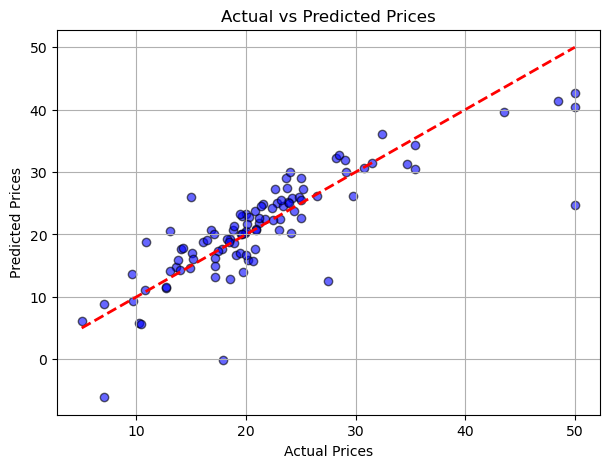

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Dataset load karna (Online URL se directly)
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

# 2. Data ko Train aur Test me split karna (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model ko train karna
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predictions nikalna
y_pred = model.predict(X_test)

# 5. Metrics evaluate karna (RMSE & R²)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Linear Regression Results ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score (Coefficient of Determination): {r2:.4f}")

# 6. Plotting: Actual vs Predicted Values
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='k')
# Ek ideal line draw kar rahe hain jahan actual == predicted ho
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

--- Logistic Regression Results ---

Classification Report:
              precision    recall  f1-score   support

  Non-Setosa       1.00      1.00      1.00        20
      Setosa       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix (Text Form):
[[20  0]
 [ 0 10]]


<Figure size 600x400 with 0 Axes>

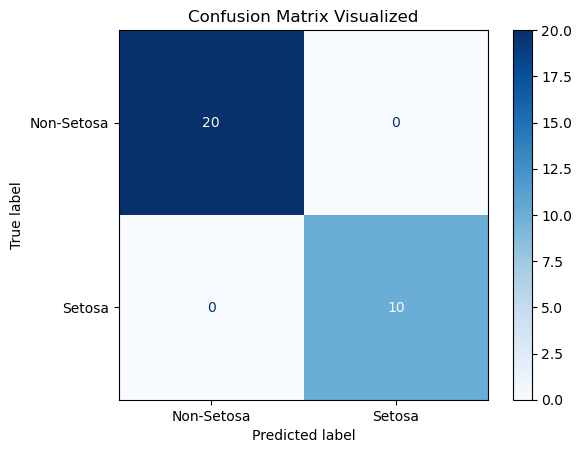

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Iris Dataset load karna
iris = load_iris()
X = iris.data
y = iris.target

# 2. Binary convert karna: Agar Setosa (0) hai toh 1, baaki sab 0 (Non-Setosa)
y_binary = np.where(y == 0, 1, 0)

# 3. Data ko Train aur Test me split karna
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# 4. Model ko train karna
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Predictions nikalna
y_pred = model.predict(X_test)

# 6. Evaluation: Print Classification Report & Confusion Matrix
print("--- Logistic Regression Results ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Setosa', 'Setosa']))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Text Form):")
print(cm)

# 7. Plotting: Confusion Matrix Visual Graph
plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Setosa', 'Setosa'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix Visualized')
plt.show()

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Dummy Dataset Create Karna (Hours Studied vs Pass/Fail)
np.random.seed(42)
hours_studied = np.random.uniform(1, 10, 100)  # 100 students jo 1 se 10 ghante padhte hain

# Agar student 5 ghante se zyada padhta hai toh pass hone ke chances zyada hain (with some noise)
pass_fail = np.where(hours_studied + np.random.normal(0, 1, 100) > 5.5, 1, 0)

# DataFrame banana
df = pd.DataFrame({'Hours_Studied': hours_studied, 'Pass_Fail': pass_fail})
X = df[['Hours_Studied']]
y = df['Pass_Fail']

# 2. Alag-alag Train/Test Split Ratios Define Karna
# 70:30 split -> test_size = 0.30
# 80:20 split -> test_size = 0.20
# 90:10 split -> test_size = 0.10
split_ratios = {
    "70:30 Split": 0.30,
    "80:20 Split": 0.20,
    "90:10 Split": 0.10
}

# Loop chalakar har split ratio par test karna
for name, test_size_ratio in split_ratios.items():
    print("=" * 50)
    print(f" NO. 1: EVALUATION FOR {name} ")
    print("=" * 50)
    
    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42)
    
    # Model ko Train karna
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Accuracy Calculate karna
    acc = accuracy_score(y_test, y_pred)
    print(f"Overall Accuracy: {acc * 100:.2f}%\n")
    
    # Classification Report Print karna
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Fail (0)', 'Pass (1)']))
    
    # Confusion Matrix Print karna
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print("\n")

 NO. 1: EVALUATION FOR 70:30 Split 
Overall Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

    Fail (0)       0.94      1.00      0.97        16
    Pass (1)       1.00      0.93      0.96        14

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[16  0]
 [ 1 13]]


 NO. 1: EVALUATION FOR 80:20 Split 
Overall Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

    Fail (0)       1.00      1.00      1.00        11
    Pass (1)       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Confusion Matrix:
[[11  0]
 [ 0  9]]


 NO. 1: EVALUATION FOR 90:10 Split 
Overall Accuracy: 100.00%

Classification Report:
           

In [6]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Iris Dataset load karna
iris = load_iris()
X_clf = iris.data
y_clf = iris.target

# 2. Isko Binary banana: Agar Setosa (0) hai toh 1, baaki sabko 0 (Non-Setosa)
y_binary = np.where(y_clf == 0, 1, 0)

# 3. Data ko Train (80%) aur Test (20%) me split karna
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_binary, test_size=0.2, random_state=42)

# 4. Logistic Regression Model train karna
clf_model = LogisticRegression()
clf_model.fit(X_train_clf, y_train_clf)

# 5. Predict karna aur Accuracy check karna
y_pred_clf = clf_model.predict(X_test_clf)
accuracy = accuracy_score(y_test_clf, y_pred_clf)

print("--- Logistic Regression Evaluation ---")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

--- Logistic Regression Evaluation ---
Model Accuracy: 100.00%


In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Boston Dataset load karna (Directly online source se)
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

# 2. Data ko Train (80%) aur Test (20%) me split karna
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model ko train karna
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# 4. Test data par predict karna
y_pred = reg_model.predict(X_test)

# 5. RMSE aur R² Score evaluate karna
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Linear Regression Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

--- Linear Regression Evaluation ---
Root Mean Squared Error (RMSE): 4.9286
R² Score: 0.6688
